# Resumo do código

Este notebook implementa duas versões para resolver o **Problema de Coloração de Grafos**, considerando a versão de decisão com $k = 3$ cores:

> Dado um grafo $G=(V,E)$, existe uma função $c:V \rightarrow \{0,1,2\}$ tal que, para toda aresta $(u,v) \in E$, vale $c(u) \ne c(v)$?

A primeira versão usa uma **solução original**, baseada em força bruta, sem poda, heurística ou redução. A segunda versão usa uma **solução otimizada**, reduzindo a coloração de grafos para uma instância SAT em forma 3-CNF e resolvendo essa instância com DPLL, propagação unitária e heurística simples de escolha de variáveis.

A fundamentação segue a linha dos materiais `PAA_12.pdf`, `PAA_13.pdf` e `PAA_TrabalhoPratico4_Otimizacao.pdf`: problemas de decisão, classes P/NP, reduções polinomiais, SAT/3-CNF-SAT e exemplos de problemas NP-Completos.

## Organização das células

1. **Grupo 1 - resumo, imports e configurações globais**: define bibliotecas, tipos, grafo de exemplo e função de execução geral.
2. **Grupo 2 - solução original**: testa todas as possíveis colorações com $3^{|V|}$ combinações.
3. **Grupo 3 - solução otimizada**: codifica coloração de grafos como SAT/3-CNF-SAT e resolve com DPLL.
4. **Grupo 4 - comparação**: mede tempo, memória, número de tentativas/decisões, plota o grafo colorido e apresenta gráficos comparativos.

```mermaid
flowchart LR
    A["Grafo G=(V,E)"] --> B["Solução original: força bruta"]
    B --> I["Grafo colorido"]
    A --> C["Redução para SAT"]
    C --> D["Conversão para 3-CNF-SAT"]
    D --> E["DPLL com propagação unitária"]
    E --> I
    I --> F["Comparação de tempo e memória"]
```

In [1]:
# Esta célula reúne os imports, as configurações globais e as estruturas básicas usadas por todas as versões.

from __future__ import annotations

from dataclasses import dataclass
from itertools import product
from time import perf_counter
import math
import random
import statistics
import tracemalloc
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt

SEMENTE_ALEATORIA = 42
NUMERO_DE_CORES = 3
CORES = tuple(range(NUMERO_DE_CORES))
NOMES_DAS_CORES = {0: "vermelho", 1: "verde", 2: "azul"}

random.seed(SEMENTE_ALEATORIA)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

Vertice = int
Aresta = Tuple[Vertice, Vertice]
Grafo = Dict[Vertice, List[Vertice]]
Literal = int
Clausula = Tuple[Literal, ...]
FormulaCNF = List[Clausula]
Atribuicao = Dict[int, bool]

@dataclass(frozen=True)
class ResultadoColoracao:
    nome: str
    colorivel: bool
    coloracao: Optional[Dict[Vertice, int]]
    tempo_segundos: float
    pico_memoria_kib: float
    tentativas: int
    complexidade_tempo: str
    complexidade_memoria: str

In [2]:
# Esta célula define funções auxiliares para criar, validar e imprimir grafos de forma padronizada.

def normalizar_arestas(arestas: Iterable[Aresta]) -> List[Aresta]:
    """Remove laços, ordena as pontas das arestas e elimina duplicatas."""
    arestas_normalizadas = set()
    for u, v in arestas:
        if u == v:
            continue
        a, b = sorted((u, v))
        arestas_normalizadas.add((a, b))
    return sorted(arestas_normalizadas)


def criar_grafo(numero_vertices: int, arestas: Iterable[Aresta]) -> Grafo:
    """Cria uma lista de adjacências para um grafo não direcionado."""
    grafo = {v: [] for v in range(numero_vertices)}
    for u, v in normalizar_arestas(arestas):
        grafo[u].append(v)
        grafo[v].append(u)
    return {v: sorted(vizinhos) for v, vizinhos in grafo.items()}


def listar_arestas(grafo: Grafo) -> List[Aresta]:
    """Retorna as arestas de um grafo sem repetição."""
    return [(u, v) for u in grafo for v in grafo[u] if u < v]


def coloracao_valida(grafo: Grafo, coloracao: Dict[Vertice, int]) -> bool:
    """Verifica se uma coloração respeita a regra de cores diferentes em vértices adjacentes."""
    if set(coloracao) != set(grafo):
        return False
    return all(coloracao[u] != coloracao[v] for u, v in listar_arestas(grafo))


def descrever_coloracao(coloracao: Optional[Dict[Vertice, int]]) -> str:
    """Formata a coloração usando nomes de cores em português."""
    if coloracao is None:
        return "sem coloração válida"
    partes = [f"v{v}: {NOMES_DAS_CORES[c]}" for v, c in sorted(coloracao.items())]
    return ", ".join(partes)

In [3]:
# Esta célula define a função de plotagem do grafo, usando uma disposição circular para facilitar a visualização.

def calcular_posicoes_circulares(grafo: Grafo, raio: float = 1.0) -> Dict[Vertice, Tuple[float, float]]:
    """Calcula posições 2D em círculo para desenhar os vértices do grafo."""
    vertices = sorted(grafo)
    total = len(vertices)
    posicoes = {}

    for indice, vertice in enumerate(vertices):
        angulo = 2 * math.pi * indice / total
        posicoes[vertice] = (raio * math.cos(angulo), raio * math.sin(angulo))

    return posicoes


def plotar_grafo_colorido(grafo: Grafo, coloracao: Optional[Dict[Vertice, int]] = None, titulo: str = "Grafo") -> None:
    """Plota o grafo e, quando disponível, colore os vértices conforme a solução encontrada."""
    mapa_cores = {0: "#d62728", 1: "#2ca02c", 2: "#1f77b4"}
    posicoes = calcular_posicoes_circulares(grafo)

    plt.figure(figsize=(7, 7))

    for u, v in listar_arestas(grafo):
        x1, y1 = posicoes[u]
        x2, y2 = posicoes[v]
        plt.plot([x1, x2], [y1, y2], color="#555555", linewidth=2, zorder=1)

    for vertice, (x, y) in posicoes.items():
        cor = "#dddddd" if coloracao is None else mapa_cores.get(coloracao[vertice], "#dddddd")
        plt.scatter(x, y, s=1200, color=cor, edgecolor="black", linewidth=2, zorder=2)
        plt.text(x, y, f"v{vertice}", ha="center", va="center", color="white", fontsize=12, weight="bold", zorder=3)

    plt.title(titulo)
    plt.axis("equal")
    plt.axis("off")
    plt.show()

In [4]:
# Esta célula cria o grafo principal usado como exemplo didático nas duas versões do algoritmo.

GRAFO_EXEMPLO = criar_grafo(
    numero_vertices=6,
    arestas=[
        (0, 1), (0, 2), (1, 2),
        (1, 3), (2, 4), (3, 4),
        (3, 5), (4, 5),
    ],
)

print("Grafo de exemplo")
print("Vértices:", list(GRAFO_EXEMPLO.keys()))
print("Arestas:", listar_arestas(GRAFO_EXEMPLO))

Grafo de exemplo
Vértices: [0, 1, 2, 3, 4, 5]
Arestas: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 5)]


In [5]:
# Esta célula declara a função de execução geral. A chamada efetiva ocorre no Grupo 4, depois que as duas versões estiverem definidas.

def executar_duas_versoes(grafo: Grafo, numero_cores: int = NUMERO_DE_CORES) -> Tuple[ResultadoColoracao, ResultadoColoracao]:
    """Executa a solução original e a solução otimizada para o mesmo grafo."""
    resultado_original = medir_execucao(
        nome="Solução original",
        funcao=lambda: colorir_forca_bruta_original(grafo, numero_cores),
        complexidade_tempo=f"O({numero_cores}^|V| · (|V|+|E|))",
        complexidade_memoria="O(|V|)",
    )
    resultado_otimizado = medir_execucao(
        nome="Solução otimizada",
        funcao=lambda: colorir_por_reducao_sat_otimizada(grafo, numero_cores),
        complexidade_tempo="exponencial no pior caso; na prática, reduzido por propagação unitária",
        complexidade_memoria="O(|V|·k + |E|·k)",
    )
    return resultado_original, resultado_otimizado

## Grupo 2 - Versão: Solução Original

A solução original enumera todas as atribuições possíveis de cores para os vértices. Para $n=|V|$ vértices e $k$ cores, existem $k^n$ combinações.

Ela não usa:

- poda;
- ordenação de vértices;
- propagação de restrições;
- redução para outro problema.

A complexidade de tempo é:

$O(k^{|V|} \cdot (|V| + |E|))$

A memória adicional principal é a atribuição corrente de cores:

$O(|V|)$

In [6]:
# Esta célula implementa a solução original por força bruta, testando todas as combinações de cores.

def colorir_forca_bruta_original(grafo: Grafo, numero_cores: int = NUMERO_DE_CORES) -> Tuple[bool, Optional[Dict[Vertice, int]], int]:
    """Resolve coloração de grafos por força bruta, sem qualquer otimização."""
    vertices = list(grafo.keys())
    tentativas = 0

    for cores_candidatas in product(range(numero_cores), repeat=len(vertices)):
        tentativas += 1
        coloracao = dict(zip(vertices, cores_candidatas))
        if coloracao_valida(grafo, coloracao):
            return True, coloracao, tentativas

    return False, None, tentativas

## Grupo 3 - Versão: Solução Otimizada com Redução para SAT/3-CNF-SAT

Para resolver a coloração de grafos de forma mais estruturada, o problema é reduzido para uma fórmula booleana.

Para cada vértice $v$ e cor $c$, cria-se uma variável booleana:

$x_{v,c} = \text{verdadeiro se o vértice } v \text{ recebe a cor } c$

As restrições são:

1. Cada vértice recebe **pelo menos uma cor**.
2. Cada vértice recebe **no máximo uma cor**.
3. Vértices adjacentes recebem **cores diferentes**.

```mermaid
flowchart TD
    A["Coloração de Grafos"] --> B["Variáveis booleanas x_v_c"]
    B --> C["Cláusulas: pelo menos uma cor"]
    B --> D["Cláusulas: no máximo uma cor"]
    B --> E["Cláusulas: arestas com cores diferentes"]
    C --> F["CNF"]
    D --> F
    E --> F
    F --> G["3-CNF-SAT"]
    G --> H["DPLL"]
```

No material teórico, $3$-CNF-SAT é usado como base para reduções de NP-Completude. Aqui, a redução é usada de forma operacional: transformamos a coloração em SAT/3-CNF-SAT e resolvemos a fórmula.

In [7]:
# Esta célula cria o mapeamento entre pares (vértice, cor) e variáveis booleanas inteiras usadas no SAT.

def criar_variaveis_sat(grafo: Grafo, numero_cores: int) -> Tuple[Dict[Tuple[Vertice, int], int], Dict[int, Tuple[Vertice, int]]]:
    """Mapeia cada par (vértice, cor) para uma variável SAT positiva."""
    variavel_por_par: Dict[Tuple[Vertice, int], int] = {}
    par_por_variavel: Dict[int, Tuple[Vertice, int]] = {}
    proxima_variavel = 1

    for vertice in sorted(grafo):
        for cor in range(numero_cores):
            variavel_por_par[(vertice, cor)] = proxima_variavel
            par_por_variavel[proxima_variavel] = (vertice, cor)
            proxima_variavel += 1

    return variavel_por_par, par_por_variavel

In [8]:
# Esta célula reduz a coloração de grafos para uma fórmula CNF que representa as restrições do problema.

def reduzir_coloracao_para_cnf(grafo: Grafo, numero_cores: int = NUMERO_DE_CORES) -> Tuple[FormulaCNF, Dict[int, Tuple[Vertice, int]]]:
    """Cria uma fórmula CNF satisfazível se, e somente se, o grafo for colorível com k cores."""
    variavel_por_par, par_por_variavel = criar_variaveis_sat(grafo, numero_cores)
    formula: FormulaCNF = []

    for vertice in sorted(grafo):
        pelo_menos_uma_cor = tuple(variavel_por_par[(vertice, cor)] for cor in range(numero_cores))
        formula.append(pelo_menos_uma_cor)

        for cor_a in range(numero_cores):
            for cor_b in range(cor_a + 1, numero_cores):
                formula.append((-variavel_por_par[(vertice, cor_a)], -variavel_por_par[(vertice, cor_b)]))

    for u, v in listar_arestas(grafo):
        for cor in range(numero_cores):
            formula.append((-variavel_por_par[(u, cor)], -variavel_por_par[(v, cor)]))

    return formula, par_por_variavel

In [9]:
# Esta célula converte cláusulas de tamanho 1 ou 2 para cláusulas de tamanho 3 por repetição de literais.

def converter_para_3_cnf(formula: FormulaCNF) -> FormulaCNF:
    """Converte uma CNF com cláusulas de até 3 literais para 3-CNF, preservando satisfazibilidade."""
    formula_3_cnf: FormulaCNF = []

    for clausula in formula:
        if len(clausula) == 1:
            literal = clausula[0]
            formula_3_cnf.append((literal, literal, literal))
        elif len(clausula) == 2:
            a, b = clausula
            formula_3_cnf.append((a, b, b))
        elif len(clausula) == 3:
            formula_3_cnf.append(clausula)
        else:
            raise ValueError("Esta conversão didática espera cláusulas com no máximo 3 literais.")

    return formula_3_cnf

In [10]:
# Esta célula implementa operações auxiliares do DPLL: avaliação de cláusulas e simplificação por atribuições.

def avaliar_literal(literal: Literal, atribuicao: Atribuicao) -> Optional[bool]:
    """Avalia um literal com base na atribuição parcial atual."""
    variavel = abs(literal)
    if variavel not in atribuicao:
        return None
    valor = atribuicao[variavel]
    return valor if literal > 0 else not valor


def simplificar_formula(formula: FormulaCNF, atribuicao: Atribuicao) -> Optional[FormulaCNF]:
    """Remove cláusulas satisfeitas e literais falsos; retorna None se houver contradição."""
    formula_simplificada: FormulaCNF = []

    for clausula in formula:
        nova_clausula = []
        clausula_satisfeita = False

        for literal in clausula:
            valor = avaliar_literal(literal, atribuicao)
            if valor is True:
                clausula_satisfeita = True
                break
            if valor is None:
                nova_clausula.append(literal)

        if clausula_satisfeita:
            continue
        if not nova_clausula:
            return None
        formula_simplificada.append(tuple(nova_clausula))

    return formula_simplificada

In [11]:
# Esta célula implementa propagação unitária e escolha heurística de variável para o DPLL.

def propagar_unitarias(formula: FormulaCNF, atribuicao: Atribuicao) -> Tuple[Optional[FormulaCNF], Atribuicao]:
    """Aplica propagação unitária até não restarem cláusulas unitárias."""
    atribuicao = dict(atribuicao)
    formula_atual = simplificar_formula(formula, atribuicao)

    while formula_atual is not None:
        clausulas_unitarias = [clausula[0] for clausula in formula_atual if len(set(clausula)) == 1]
        if not clausulas_unitarias:
            break

        houve_mudanca = False
        for literal in clausulas_unitarias:
            variavel = abs(literal)
            valor = literal > 0
            if variavel in atribuicao and atribuicao[variavel] != valor:
                return None, atribuicao
            if variavel not in atribuicao:
                atribuicao[variavel] = valor
                houve_mudanca = True

        if not houve_mudanca:
            break
        formula_atual = simplificar_formula(formula_atual, atribuicao)

    return formula_atual, atribuicao


def escolher_variavel(formula: FormulaCNF, atribuicao: Atribuicao) -> int:
    """Escolhe a variável ainda não atribuída que aparece com maior frequência."""
    frequencias: Dict[int, int] = {}
    for clausula in formula:
        for literal in clausula:
            variavel = abs(literal)
            if variavel not in atribuicao:
                frequencias[variavel] = frequencias.get(variavel, 0) + 1
    return max(frequencias, key=frequencias.get)

In [12]:
# Esta célula implementa o solucionador DPLL usado na versão otimizada.

def resolver_dpll(formula: FormulaCNF, atribuicao: Optional[Atribuicao] = None, estatisticas: Optional[Dict[str, int]] = None) -> Tuple[bool, Atribuicao, Dict[str, int]]:
    """Resolve uma fórmula CNF usando DPLL com propagação unitária."""
    if atribuicao is None:
        atribuicao = {}
    if estatisticas is None:
        estatisticas = {"decisoes": 0, "chamadas": 0}

    estatisticas["chamadas"] += 1
    formula_atual, atribuicao_atual = propagar_unitarias(formula, atribuicao)

    if formula_atual is None:
        return False, atribuicao_atual, estatisticas
    if not formula_atual:
        return True, atribuicao_atual, estatisticas

    variavel = escolher_variavel(formula_atual, atribuicao_atual)

    for valor in (True, False):
        estatisticas["decisoes"] += 1
        nova_atribuicao = dict(atribuicao_atual)
        nova_atribuicao[variavel] = valor
        satisfazivel, solucao, estatisticas = resolver_dpll(formula_atual, nova_atribuicao, estatisticas)
        if satisfazivel:
            return True, solucao, estatisticas

    return False, atribuicao_atual, estatisticas

In [13]:
# Esta célula reconstrói a coloração do grafo a partir da atribuição booleana encontrada pelo DPLL.

def reconstruir_coloracao(atribuicao: Atribuicao, par_por_variavel: Dict[int, Tuple[Vertice, int]], grafo: Grafo) -> Optional[Dict[Vertice, int]]:
    """Converte variáveis SAT verdadeiras de volta para cores dos vértices."""
    coloracao: Dict[Vertice, int] = {}

    for variavel, valor in atribuicao.items():
        if valor and variavel in par_por_variavel:
            vertice, cor = par_por_variavel[variavel]
            if vertice not in coloracao:
                coloracao[vertice] = cor

    if set(coloracao) != set(grafo):
        return None
    if not coloracao_valida(grafo, coloracao):
        return None
    return coloracao


def colorir_por_reducao_sat_otimizada(grafo: Grafo, numero_cores: int = NUMERO_DE_CORES) -> Tuple[bool, Optional[Dict[Vertice, int]], int]:
    """Resolve coloração por redução para SAT/3-CNF-SAT e DPLL."""
    formula_cnf, par_por_variavel = reduzir_coloracao_para_cnf(grafo, numero_cores)
    formula_3_cnf = converter_para_3_cnf(formula_cnf)
    satisfazivel, atribuicao, estatisticas = resolver_dpll(formula_3_cnf)

    if not satisfazivel:
        return False, None, estatisticas["decisoes"]

    coloracao = reconstruir_coloracao(atribuicao, par_por_variavel, grafo)
    return coloracao is not None, coloracao, estatisticas["decisoes"]

## Grupo 4 - Comparação Estatística e Gráficos

A comparação mede:

- tempo de execução em segundos;
- pico de memória observado com `tracemalloc`;
- número de tentativas na força bruta;
- número de decisões no DPLL;
- ordens de complexidade associadas.

A força bruta tem crescimento esperado $O(3^{|V|})$ para $k=3$. A versão otimizada continua tendo pior caso exponencial, pois SAT e coloração são problemas NP-Completos, mas a redução e o DPLL evitam grande parte das combinações por meio de propagação de restrições.

In [14]:
# Esta célula mede tempo e memória de uma função de coloração, padronizando os resultados para comparação.

def medir_execucao(nome: str, funcao, complexidade_tempo: str, complexidade_memoria: str) -> ResultadoColoracao:
    """Executa uma função de coloração e coleta estatísticas de tempo e memória."""
    tracemalloc.start()
    inicio = perf_counter()
    colorivel, coloracao, tentativas = funcao()
    tempo = perf_counter() - inicio
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return ResultadoColoracao(
        nome=nome,
        colorivel=colorivel,
        coloracao=coloracao,
        tempo_segundos=tempo,
        pico_memoria_kib=pico / 1024,
        tentativas=tentativas,
        complexidade_tempo=complexidade_tempo,
        complexidade_memoria=complexidade_memoria,
    )

In [15]:
# Esta célula executa as duas versões no grafo de exemplo e imprime os resultados principais.

resultado_original, resultado_otimizado = executar_duas_versoes(GRAFO_EXEMPLO)

for resultado in (resultado_original, resultado_otimizado):
    print(f"{resultado.nome}")
    print("  Colorível:", "sim" if resultado.colorivel else "não")
    print("  Coloração:", descrever_coloracao(resultado.coloracao))
    print(f"  Tempo: {resultado.tempo_segundos:.6f} s")
    print(f"  Pico de memória: {resultado.pico_memoria_kib:.2f} KiB")
    print(f"  Tentativas/decisões: {resultado.tentativas}")
    print("  Complexidade de tempo:", resultado.complexidade_tempo)
    print("  Complexidade de memória:", resultado.complexidade_memoria)
    print()

Solução original
  Colorível: sim
  Coloração: v0: vermelho, v1: verde, v2: azul, v3: vermelho, v4: verde, v5: azul
  Tempo: 0.000838 s
  Pico de memória: 6.12 KiB
  Tentativas/decisões: 141
  Complexidade de tempo: O(3^|V| · (|V|+|E|))
  Complexidade de memória: O(|V|)

Solução otimizada
  Colorível: sim
  Coloração: v0: verde, v1: vermelho, v2: azul, v3: verde, v4: vermelho, v5: azul
  Tempo: 0.000385 s
  Pico de memória: 15.18 KiB
  Tentativas/decisões: 2
  Complexidade de tempo: exponencial no pior caso; na prática, reduzido por propagação unitária
  Complexidade de memória: O(|V|·k + |E|·k)



### Visualização do grafo de exemplo

A célula seguinte mostra o grafo usado no exemplo. As cores dos vértices representam uma coloração válida encontrada pelos algoritmos, isto é, nenhuma aresta liga dois vértices com a mesma cor.

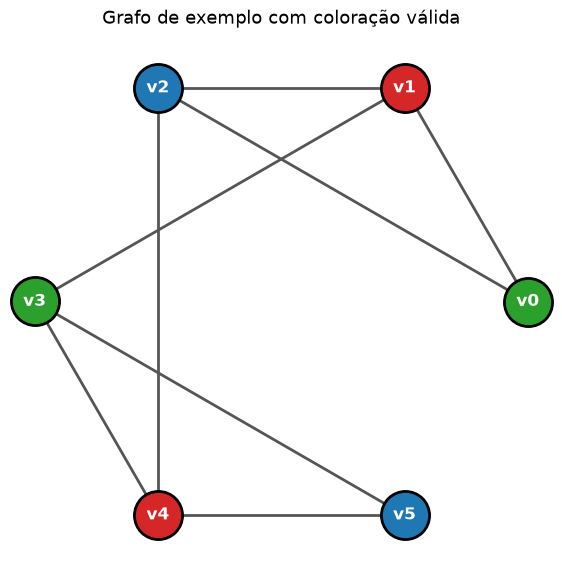

In [16]:
# Esta célula plota o grafo de exemplo usando a coloração encontrada pela solução otimizada.

plotar_grafo_colorido(
    GRAFO_EXEMPLO,
    resultado_otimizado.coloracao,
    "Grafo de exemplo com coloração válida",
)

In [17]:
# Esta célula gera grafos completos K_n para criar instâncias difíceis quando n > 3, pois não são 3-coloríveis.

def criar_grafo_completo(numero_vertices: int) -> Grafo:
    """Cria o grafo completo K_n."""
    return criar_grafo(numero_vertices, ((u, v) for u in range(numero_vertices) for v in range(u + 1, numero_vertices)))


def comparar_em_varios_tamanhos(tamanhos: Sequence[int], repeticoes: int = 1) -> List[Dict[str, float]]:
    """Executa as duas versões em diferentes tamanhos de grafos completos."""
    linhas = []

    for n in tamanhos:
        grafo = criar_grafo_completo(n)
        for repeticao in range(repeticoes):
            original, otimizado = executar_duas_versoes(grafo)
            linhas.append({
                "vertices": n,
                "arestas": len(listar_arestas(grafo)),
                "algoritmo": original.nome,
                "tempo": original.tempo_segundos,
                "memoria": original.pico_memoria_kib,
                "tentativas": original.tentativas,
            })
            linhas.append({
                "vertices": n,
                "arestas": len(listar_arestas(grafo)),
                "algoritmo": otimizado.nome,
                "tempo": otimizado.tempo_segundos,
                "memoria": otimizado.pico_memoria_kib,
                "tentativas": otimizado.tentativas,
            })

    return linhas

estatisticas = comparar_em_varios_tamanhos(tamanhos=range(3, 10), repeticoes=1)
print("Estatísticas coletadas:")
for linha in estatisticas:
    print(linha)

Estatísticas coletadas:
{'vertices': 3, 'arestas': 3, 'algoritmo': 'Solução original', 'tempo': 4.162500408710912e-05, 'memoria': 1.1953125, 'tentativas': 6}
{'vertices': 3, 'arestas': 3, 'algoritmo': 'Solução otimizada', 'tempo': 0.00016908300312934443, 'memoria': 5.671875, 'tentativas': 2}
{'vertices': 4, 'arestas': 6, 'algoritmo': 'Solução original', 'tempo': 0.00040133299626177177, 'memoria': 3.984375, 'tentativas': 81}
{'vertices': 4, 'arestas': 6, 'algoritmo': 'Solução otimizada', 'tempo': 0.0006867910051369108, 'memoria': 13.984375, 'tentativas': 10}
{'vertices': 5, 'arestas': 10, 'algoritmo': 'Solução original', 'tempo': 0.0014190419969963841, 'memoria': 1.609375, 'tentativas': 243}
{'vertices': 5, 'arestas': 10, 'algoritmo': 'Solução otimizada', 'tempo': 0.001131459001044277, 'memoria': 15.5068359375, 'tentativas': 10}
{'vertices': 6, 'arestas': 15, 'algoritmo': 'Solução original', 'tempo': 0.004892832999757957, 'memoria': 1.6875, 'tentativas': 729}
{'vertices': 6, 'arestas': 

In [18]:
# Esta célula prepara séries numéricas para os gráficos comparativos.

def serie_por_algoritmo(estatisticas: List[Dict[str, float]], campo: str, algoritmo: str) -> Tuple[List[int], List[float]]:
    """Extrai uma série ordenada por número de vértices para um algoritmo e métrica."""
    filtradas = [linha for linha in estatisticas if linha["algoritmo"] == algoritmo]
    filtradas.sort(key=lambda linha: linha["vertices"])
    return [int(linha["vertices"]) for linha in filtradas], [float(linha[campo]) for linha in filtradas]

vertices_original, tempo_original = serie_por_algoritmo(estatisticas, "tempo", "Solução original")
vertices_otimizado, tempo_otimizado = serie_por_algoritmo(estatisticas, "tempo", "Solução otimizada")
_, memoria_original = serie_por_algoritmo(estatisticas, "memoria", "Solução original")
_, memoria_otimizado = serie_por_algoritmo(estatisticas, "memoria", "Solução otimizada")
_, tentativas_original = serie_por_algoritmo(estatisticas, "tentativas", "Solução original")
_, decisoes_otimizado = serie_por_algoritmo(estatisticas, "tentativas", "Solução otimizada")
referencia_exponencial = [NUMERO_DE_CORES ** n for n in vertices_original]

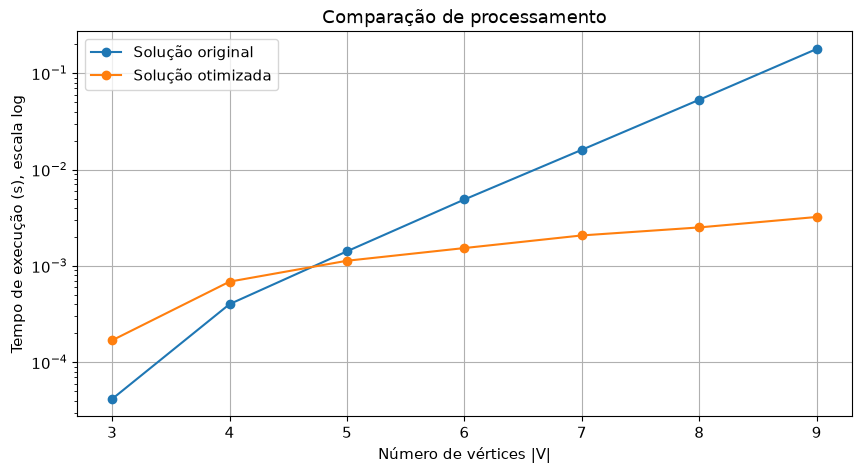

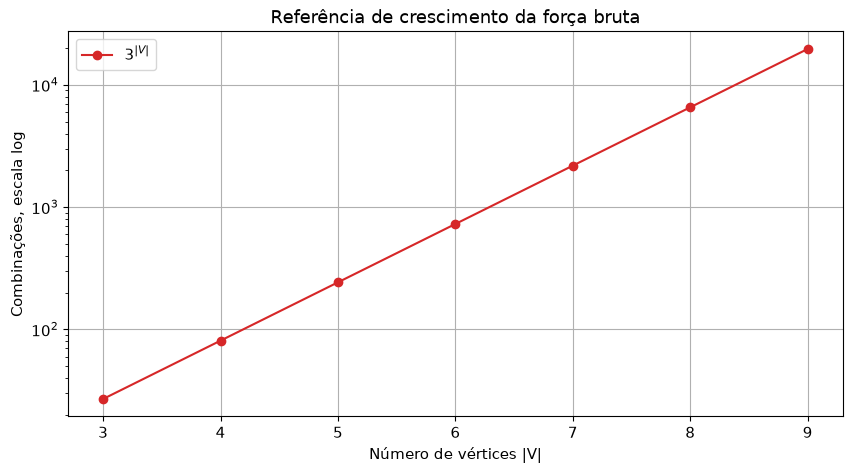

In [19]:
# Esta célula plota o tempo de execução das duas versões e a referência teórica 3^n em escala logarítmica.

plt.figure()
plt.plot(vertices_original, tempo_original, marker="o", label="Solução original")
plt.plot(vertices_otimizado, tempo_otimizado, marker="o", label="Solução otimizada")
plt.yscale("log")
plt.xlabel("Número de vértices |V|")
plt.ylabel("Tempo de execução (s), escala log")
plt.title("Comparação de processamento")
plt.legend()
plt.show()

plt.figure()
plt.plot(vertices_original, referencia_exponencial, marker="o", color="tab:red", label="$3^{|V|}$")
plt.yscale("log")
plt.xlabel("Número de vértices |V|")
plt.ylabel("Combinações, escala log")
plt.title("Referência de crescimento da força bruta")
plt.legend()
plt.show()

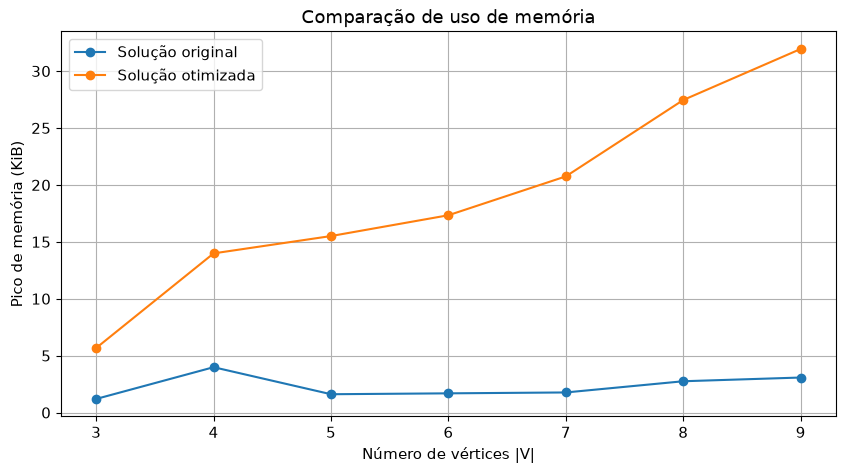

In [20]:
# Esta célula plota o uso de memória observado durante a execução das duas versões.

plt.figure()
plt.plot(vertices_original, memoria_original, marker="o", label="Solução original")
plt.plot(vertices_otimizado, memoria_otimizado, marker="o", label="Solução otimizada")
plt.xlabel("Número de vértices |V|")
plt.ylabel("Pico de memória (KiB)")
plt.title("Comparação de uso de memória")
plt.legend()
plt.show()

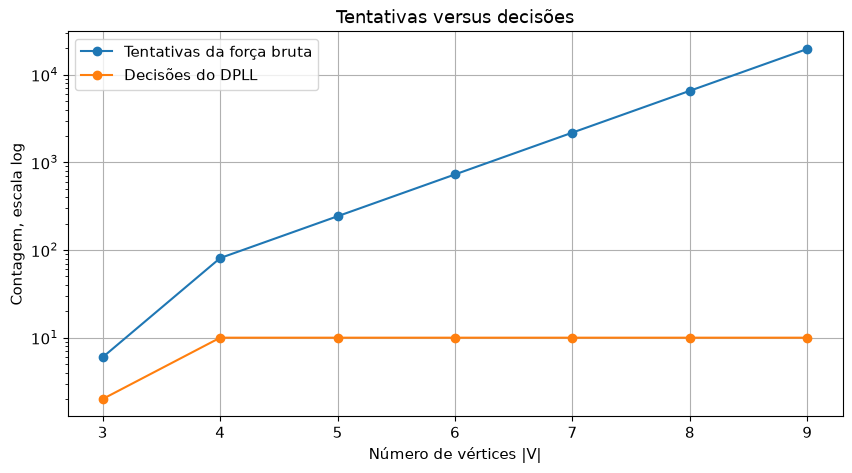

In [21]:
# Esta célula compara o número de tentativas da força bruta com o número de decisões do DPLL.

plt.figure()
plt.plot(vertices_original, tentativas_original, marker="o", label="Tentativas da força bruta")
plt.plot(vertices_otimizado, decisoes_otimizado, marker="o", label="Decisões do DPLL")
plt.yscale("log")
plt.xlabel("Número de vértices |V|")
plt.ylabel("Contagem, escala log")
plt.title("Tentativas versus decisões")
plt.legend()
plt.show()

In [22]:
# Esta célula mostra uma síntese textual das ordens de complexidade e das estatísticas finais observadas.

print("Síntese das complexidades")
print("- Solução original:")
print("  Tempo: O(k^|V| · (|V|+|E|)); para k=3, O(3^|V| · (|V|+|E|)).")
print("  Memória: O(|V|), considerando a coloração candidata atual.")
print("- Solução otimizada:")
print("  Redução: cria O(|V|·k) variáveis e O(|V|·k^2 + |E|·k) cláusulas.")
print("  DPLL: exponencial no pior caso, mas com redução prática por propagação unitária e escolha heurística de variáveis.")
print("  Memória: O(|V|·k + |E|·k), considerando a fórmula e a atribuição booleana.")
print()

melhor_tempo_original = statistics.mean(tempo_original)
melhor_tempo_otimizado = statistics.mean(tempo_otimizado)
print(f"Tempo médio da solução original: {melhor_tempo_original:.6f} s")
print(f"Tempo médio da solução otimizada: {melhor_tempo_otimizado:.6f} s")
print(f"Memória média da solução original: {statistics.mean(memoria_original):.2f} KiB")
print(f"Memória média da solução otimizada: {statistics.mean(memoria_otimizado):.2f} KiB")

Síntese das complexidades
- Solução original:
  Tempo: O(k^|V| · (|V|+|E|)); para k=3, O(3^|V| · (|V|+|E|)).
  Memória: O(|V|), considerando a coloração candidata atual.
- Solução otimizada:
  Redução: cria O(|V|·k) variáveis e O(|V|·k^2 + |E|·k) cláusulas.
  DPLL: exponencial no pior caso, mas com redução prática por propagação unitária e escolha heurística de variáveis.
  Memória: O(|V|·k + |E|·k), considerando a fórmula e a atribuição booleana.

Tempo médio da solução original: 0.036345 s
Tempo médio da solução otimizada: 0.001617 s
Memória média da solução original: 2.30 KiB
Memória média da solução otimizada: 18.95 KiB
